## **Figure-S10**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')

condition = dict(orig='Initial', refined='Reconstructed', tl='Transfer-Learn', onlyFilter='Only-Filter')

## **Load Data**

#### **Load Identifications (For Jaccard Index)**

In [4]:
osw = { n:defaultdict(dict) for n in names.values() }

# Bruker data
osw[names['bruker']][condition['tl']]['1'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['bruker']][condition['tl']]['2'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['bruker']][condition['tl']]['3'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['bruker']][condition['onlyFilter']]['1'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['onlyFilter']]['2'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['onlyFilter']]['3'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Panhuman data
osw[names['panhuman']][condition['tl'] ]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['tl'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['tl'] ]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['onlyFilter'] ]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['onlyFilter'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['onlyFilter'] ]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['tl']]['1'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['exp']][condition['tl']]['2'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['exp']][condition['tl']]['3'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['exp']][condition['onlyFilter']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['onlyFilter']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['onlyFilter']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")


# Silico data
osw[names['silico']][condition['tl'] ]['1'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['tl'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['tl'] ]['3'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['silico']][condition['onlyFilter']]['1'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['silico']][condition['onlyFilter']]['2'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['silico']][condition['onlyFilter']]['3'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet

In [5]:
diann = { n:defaultdict(dict) for n in names.values() }

# Bruker data
diann[names['bruker']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['bruker']][condition['onlyFilter']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['onlyFilter']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['onlyFilter']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")


# Silico data
diann[names['silico']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['silico']][condition['onlyFilter']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['onlyFilter']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['onlyFilter']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")


# exp data
diann[names['exp']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

diann[names['exp']][condition['onlyFilter']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['onlyFilter']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['onlyFilter']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)


# Panhuman data
diann[names['panhuman']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['panhuman']][condition['onlyFilter']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['onlyFilter']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['onlyFilter']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_onlyFilter/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
.

In [6]:
avg_jaccards = defaultdict(dict)
for lib, v in osw.items():
    for cond, vv in v.items():
        avg_jaccards[lib][cond] = avg_jaccard_index(vv)

avg_jaccards_osw = pd.DataFrame(avg_jaccards).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Jaccard Index')

In [7]:
avg_jaccards = defaultdict(dict)
for lib, v in diann.items():
    for cond, vv in v.items():
        avg_jaccards[lib][cond] = avg_jaccard_index(vv)

avg_jaccards_diann = pd.DataFrame(avg_jaccards).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Jaccard Index')

In [8]:
avg_ids = defaultdict(dict)
for lib, v in osw.items():
    for cond, vv in v.items():
        avg_ids[lib][cond] = np.array([ len(i) for i in vv.values() ] ).mean()

avg_ids_osw = pd.DataFrame(avg_ids).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Average # IDs')

In [9]:
avg_ids = defaultdict(dict)
for lib, v in diann.items():
    for cond, vv in v.items():
        avg_ids[lib][cond] = np.array([ len(i) for i in vv.values() ] ).mean()

avg_ids_diann = pd.DataFrame(avg_ids).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Average # IDs')

In [10]:
avg_jaccards_diann['Software'] = 'DIA-NN'
avg_jaccards_osw['Software'] = 'OpenSWATH'

avg_jaccards = pd.concat([avg_jaccards_diann, avg_jaccards_osw])

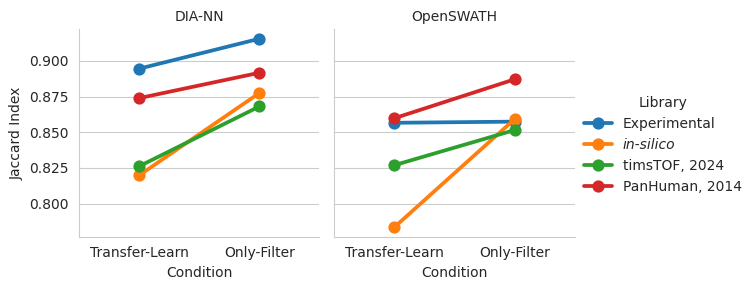

In [11]:
sns.set_style("whitegrid") 
g = sns.catplot(data=avg_jaccards, x='Condition', y='Jaccard Index', hue='Library', kind='point', col='Software', height=3)
g.set_titles("{col_name}")
g.legend.get_texts()[1].set_style('italic')
plt.savefig("Figure-S10.png", dpi=300)
